# 🖼️ Basic Image Processing with OpenCV and Pillow


<a href="https://colab.research.google.com/github/rubenfonnegra/machine_learning/blob/master/Sem_01/image_processing_basics.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a> 
<a href="https://github.com/rubenfonnegra/machine_learning/blob/master/Sem_01/image_processing_basics.ipynb" target="_parent"><img src="https://img.shields.io/badge/%E2%80%8B-Open%20in%20Github-blue?logo=github" alt="Open In Github"/></a> 


### Learning objectives

By the end of this notebook, you will be able to:

- Open and display an image.
- Understand RGB and BGR channel order.
- Separate and modify color channels.
- Resize an image.
- Convert an image to grayscale.
- Extract a Region of Interest (ROI).
- Compare equivalent operations in OpenCV and Pillow.


# 1. Install and Import the Libraries

Uncomment the installation line only if the libraries are not already available.


In [48]:
# !pip install opencv-python pillow matplotlib

import os
import cv2
import numpy as np
import matplotlib.pyplot as plt

from PIL import Image

# 2. Prepare an Example Image

Download the image [lena.jpg](https://drive.google.com/file/d/1gH5sJN__2g7f9ndLhLvTECdOBJIGUbg_/view) before getting started. Then, upload the image to Colab / Environment and change `IMAGE_PATH` with your own image path.


In [11]:
# IMAGE_PATH = "/content/lena.jpg"
IMAGE_PATH = "../Images/lena.jpg"

# 3. Open an Image with Pillow

Pillow loads color images using the **RGB** channel order.


Image format: JPEG
Image mode: RGB
Image size: (400, 300)


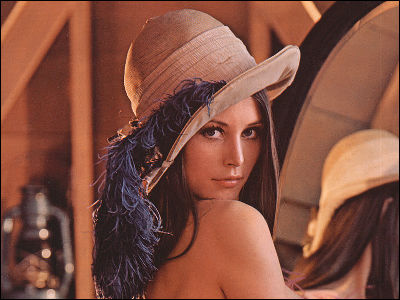

In [12]:
pil_image = Image.open(IMAGE_PATH)

print("Image format:", pil_image.format)
print("Image mode:", pil_image.mode)
print("Image size:", pil_image.size)

pil_image


# 4. Open an Image with OpenCV

OpenCV loads color images using the **BGR** channel order by default.

- Pillow: Red, Green, Blue
- OpenCV: Blue, Green, Red


In [14]:
cv_image_bgr = cv2.imread(IMAGE_PATH)

if cv_image_bgr is None:
    raise FileNotFoundError(f"Could not open image: {IMAGE_PATH}")

print("OpenCV image shape:", cv_image_bgr.shape)
print("Data type:", cv_image_bgr.dtype)


OpenCV image shape: (300, 400, 3)
Data type: uint8


## Display an OpenCV Image Correctly with Matplotlib

Matplotlib expects RGB images, so convert the OpenCV image first.


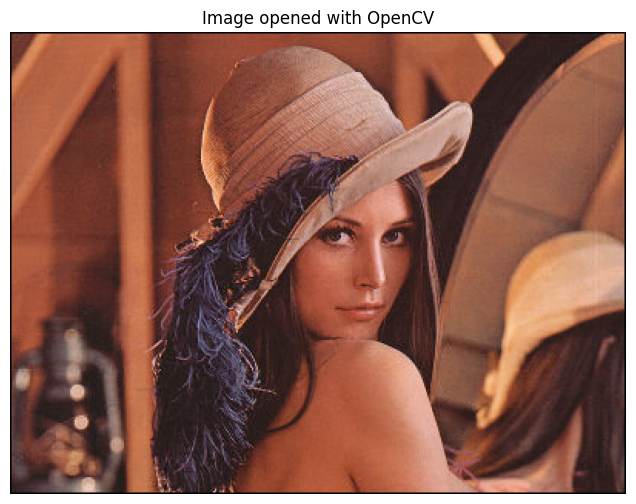

In [15]:
cv_image_rgb = cv2.cvtColor(cv_image_bgr, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(9, 6))
plt.imshow(cv_image_rgb)
plt.title("Image opened with OpenCV")
plt.axis("off")
plt.show()


# 5. Compare Pillow and OpenCV Images

Both libraries can represent an image as a NumPy array.


In [16]:
pil_array = np.array(pil_image)

print("Pillow array shape:", pil_array.shape)
print("OpenCV array shape:", cv_image_bgr.shape)

print("Pillow first pixel:", pil_array[0, 0])
print("OpenCV first pixel:", cv_image_bgr[0, 0])


Pillow array shape: (300, 400, 3)
OpenCV array shape: (300, 400, 3)
Pillow first pixel: [0 6 7]
OpenCV first pixel: [7 6 0]


# 6. Separate Color Channels with OpenCV

Because OpenCV uses BGR, `cv2.split()` returns blue, green, and red.


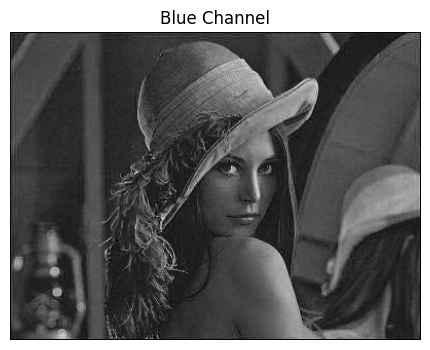

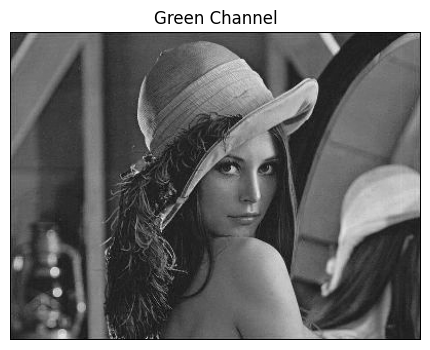

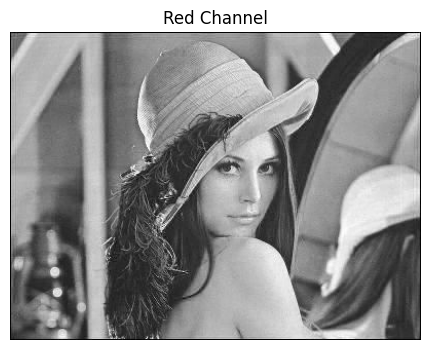

In [17]:
blue_channel, green_channel, red_channel = cv2.split(cv_image_bgr)

plt.figure(figsize=(6, 4))
plt.imshow(blue_channel, cmap="gray")
plt.title("Blue Channel")
plt.axis("off")
plt.show()

plt.figure(figsize=(6, 4))
plt.imshow(green_channel, cmap="gray")
plt.title("Green Channel")
plt.axis("off")
plt.show()

plt.figure(figsize=(6, 4))
plt.imshow(red_channel, cmap="gray")
plt.title("Red Channel")
plt.axis("off")
plt.show()


# 7. Change Color Channels with OpenCV

The following example removes the blue channel.


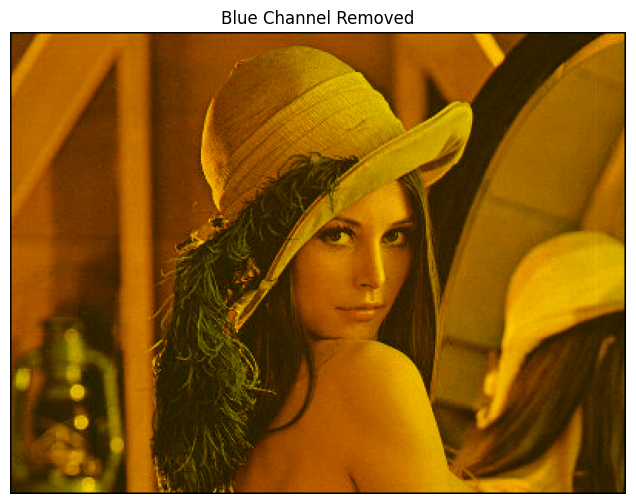

In [18]:
modified_bgr = cv_image_bgr.copy()
modified_bgr[:, :, 0] = 0

modified_rgb = cv2.cvtColor(modified_bgr, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(9, 6))
plt.imshow(modified_rgb)
plt.title("Blue Channel Removed")
plt.axis("off")
plt.show()


## Keep Only the Red Channel


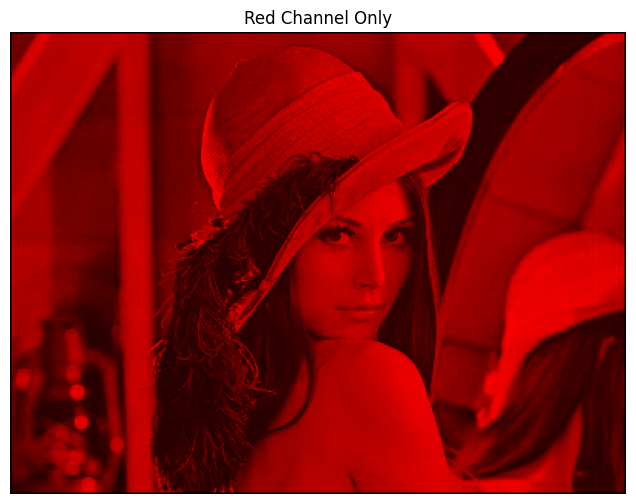

In [19]:
red_only_bgr = np.zeros_like(cv_image_bgr)
red_only_bgr[:, :, 2] = cv_image_bgr[:, :, 2]

red_only_rgb = cv2.cvtColor(red_only_bgr, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(9, 6))
plt.imshow(red_only_rgb)
plt.title("Red Channel Only")
plt.axis("off")
plt.show()


# 8. Change Color Channels with Pillow

Pillow uses RGB order. The `split()` method returns red, green, and blue.


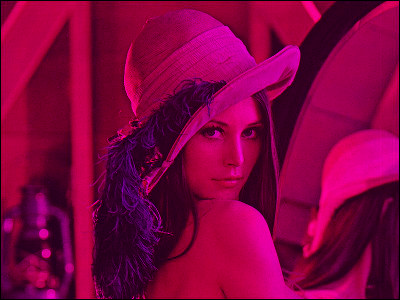

In [20]:
red_pil, green_pil, blue_pil = pil_image.split()

zero_channel = Image.new("L", pil_image.size, 0)

pil_without_green = Image.merge(
    "RGB",
    (red_pil, zero_channel, blue_pil)
)

pil_without_green


# 9. Resize an Image with OpenCV

OpenCV uses the size order `(width, height)`.


Original shape: (300, 400, 3)
Resized shape: (210, 320, 3)


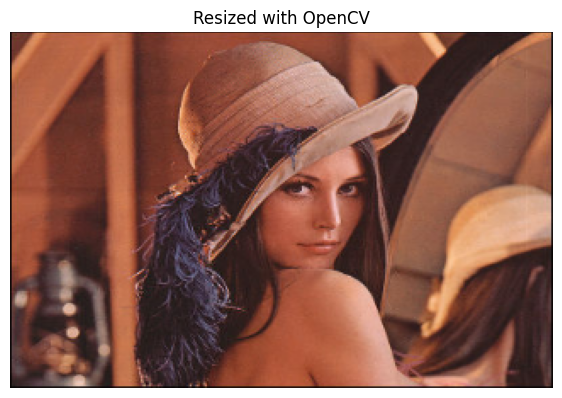

In [24]:
new_width = 320
new_height = 210

resized_cv = cv2.resize(
    cv_image_rgb,
    (new_width, new_height))

print("Original shape:", cv_image_rgb.shape)
print("Resized shape:", resized_cv.shape)

plt.figure(figsize=(7, 5))
plt.imshow(resized_cv)
plt.title("Resized with OpenCV")
plt.axis("off")
plt.show()


## Resize While Preserving the Aspect Ratio


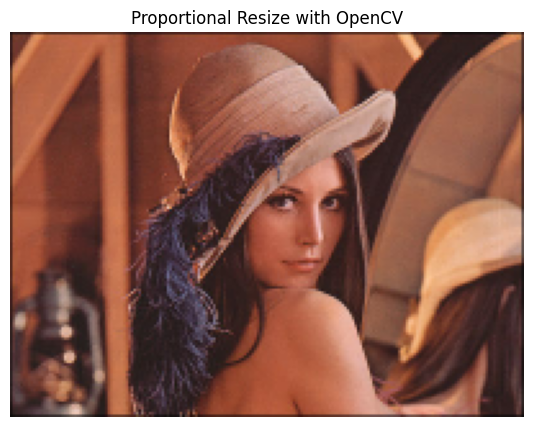

In [25]:
original_height, original_width = cv_image_rgb.shape[:2]
scale_factor = 0.5

scaled_width = int(original_width * scale_factor)
scaled_height = int(original_height * scale_factor)

resized_proportional_cv = cv2.resize(
    cv_image_rgb,
    (scaled_width, scaled_height) )

plt.figure(figsize=(7, 5))
plt.imshow(resized_proportional_cv)
plt.title("Proportional Resize with OpenCV")
plt.axis("off")
plt.show()


# 10. Resize an Image with Pillow


Original size: (400, 300)
Resized size: (320, 210)


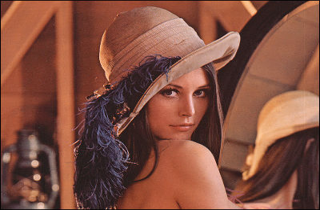

In [ ]:
resized_pil = pil_image.resize( (new_width, new_height) )

print("Original size:", pil_image.size)
print("Resized size:", resized_pil.size)

resized_pil


# 11. Convert an Image to Grayscale with OpenCV


Color image shape: (300, 400, 3)
Grayscale image shape: (300, 400)


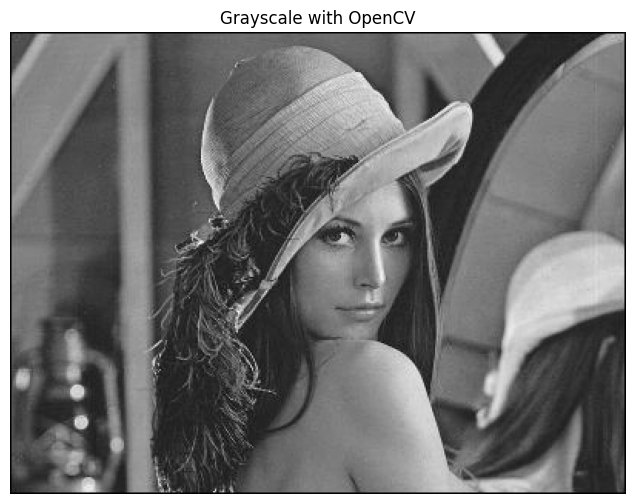

In [28]:
gray_cv = cv2.cvtColor(cv_image_bgr, cv2.COLOR_BGR2GRAY)

print("Color image shape:", cv_image_bgr.shape)
print("Grayscale image shape:", gray_cv.shape)

plt.figure(figsize=(9, 6))
plt.imshow(gray_cv, cmap="gray")
plt.title("Grayscale with OpenCV")
plt.axis("off")
plt.show()


# 12. Convert an Image to Grayscale with Pillow

Pillow uses mode `"L"` for grayscale images.


Original mode: RGB
Grayscale mode: L


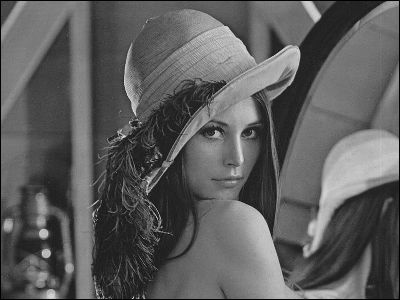

In [29]:
gray_pil = pil_image.convert("L")

print("Original mode:", pil_image.mode)
print("Grayscale mode:", gray_pil.mode)

gray_pil


# 13. Extract a Region of Interest with OpenCV

OpenCV uses NumPy slicing:

```python
roi = image[y1:y2, x1:x2]
```

Rows represent `y`, and columns represent `x`.


ROI shape: (100, 100, 3)


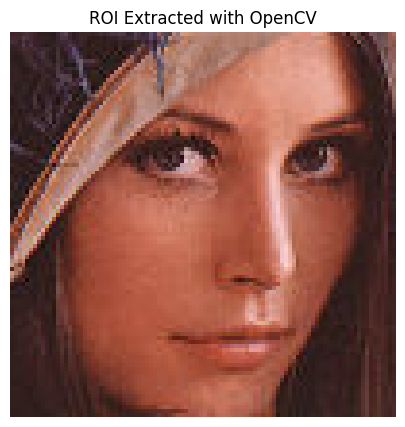

In [37]:
height, width = cv_image_rgb.shape[:2]

ir = 100
ic = 170
fr = 200
fc = 270

roi_cv = cv_image_rgb[ir:fr, ic:fc]

print("ROI shape:", roi_cv.shape)

plt.figure(figsize=(7, 5))
plt.imshow(roi_cv)
plt.title("ROI Extracted with OpenCV")
plt.axis("off")
plt.show()


## Display the ROI Position on the Original Image


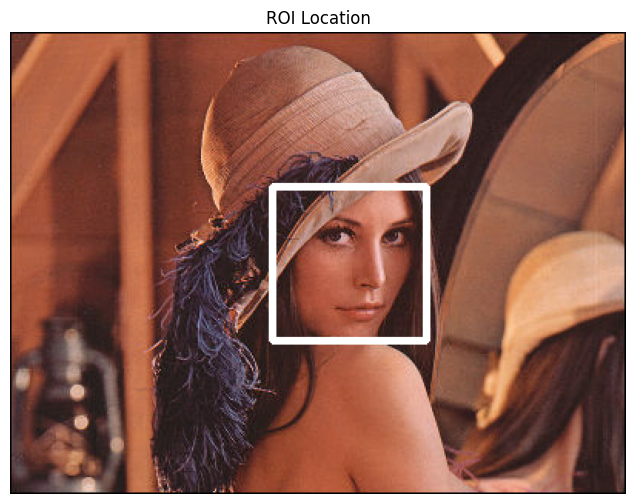

In [44]:
image_with_roi = cv_image_rgb.copy()

cv2.rectangle(
    image_with_roi,
    (ic, ir),
    (fc, fr),
    (255, 255, 255),
    4
)

plt.figure(figsize=(9, 6))
plt.imshow(image_with_roi)
plt.title("ROI Location")
plt.axis("off")
plt.show()


# 14. Extract a Region of Interest with Pillow

Pillow uses `crop((left, upper, right, lower))`.


ROI size: (100, 100)


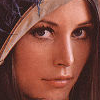

In [47]:
roi_pil = pil_image.crop((ic, ir, fc, fr))

print("ROI size:", roi_pil.size)

roi_pil


# 15. Save Processed Images


In [54]:
OUTPUT_DIR = "processed_images/"
os.makedirs(OUTPUT_DIR, exist_ok=True)

cv2.imwrite(OUTPUT_DIR + "grayscale_opencv.jpg", gray_cv)

cv2.imwrite(
    OUTPUT_DIR + "roi_opencv.jpg",
    cv2.cvtColor(roi_cv, cv2.COLOR_RGB2BGR)
)

gray_pil.save(OUTPUT_DIR + "grayscale_pillow.jpg")
roi_pil.save(OUTPUT_DIR + "roi_pillow.jpg")

print("Images saved in:", OUTPUT_DIR)


Images saved in: processed_images/


# 16. OpenCV and Pillow: Quick Comparison

| Operation | OpenCV | Pillow |
|---|---|---|
| Open image | `cv2.imread()` | `Image.open()` |
| Default color order | BGR | RGB |
| Resize | `cv2.resize()` | `image.resize()` |
| Grayscale | `cv2.cvtColor()` | `image.convert("L")` |
| ROI | NumPy slicing | `image.crop()` |
| Save image | `cv2.imwrite()` | `image.save()` |
| Array conversion | Already NumPy | `np.array(image)` |


# 17. Practice Exercises

## Exercise 1: Channel Removal

Using OpenCV:

1. Make a copy of the original image.
2. Remove the red channel.
3. Display the result.


In [ ]:
# Your code here

## Exercise 2: Resize

Using Pillow:

1. Resize the image to 200 × 200 pixels.
2. Display the result.
3. Print its new size.


In [ ]:
# Your code here

## Exercise 3: Grayscale ROI

Using OpenCV:

1. Convert the original image to grayscale.
2. Extract a rectangular ROI.
3. Display only the grayscale ROI.


In [ ]:
# Your code here

## Exercise 4: Function

Create a function called `process_image()` that:

1. Receives an image path.
2. Opens the image with Pillow.
3. Converts it to grayscale.
4. Resizes it to a specified width and height.
5. Returns the processed image.


In [ ]:
# Your code here

# 18. Final Challenge ⭐

Create an image-processing pipeline that:

1. Opens an image with OpenCV.
2. Converts it from BGR to RGB.
3. Resizes it to 50% of its original size.
4. Extracts a ROI from the center.
5. Converts the ROI to grayscale.
6. Displays the original image, resized image, ROI, and grayscale ROI.
7. Saves the final grayscale ROI.

Try to organize the solution using one or more functions.


In [ ]:
# Your code here

# ✅ Summary

You reviewed how to:

- Open images with OpenCV and Pillow.
- Understand RGB and BGR channel order.
- Separate and modify color channels.
- Resize images.
- Preserve the aspect ratio.
- Convert images to grayscale.
- Extract rectangular Regions of Interest.
- Save processed images.
- Convert between Pillow images and NumPy arrays.
